# Tutorial 2 - Event-Based Data (DVSGesture)

In this notebook, we load and visualize event-based data from the **DVSGesture** dataset using `tonic`.

The events are converted into frame slices over a fixed time window, then displayed as positive and negative polarities side by side.

## 1. Import libraries

We import `tonic` for neuromorphic datasets/transforms, `cv2` for visualization, and `numpy` for array manipulation.

In [1]:
import tonic
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import time

## 2. Load DVSGesture events

We select the dataset path and load the training split.
Then we choose one trial (`user_trial`) to inspect.

In [2]:
# Step 1: Load the Events from the DVSGesture Dataset
# Specify the path to your dataset
path = 'data/'
dvs_training = tonic.datasets.DVSGesture(path, train=True)

# Define parameters for the event processing
time_window = 10000  # Time window in microseconds (10 ms)
user_trial = 1      # Index of the user trial to analyze

# Load events and corresponding numpy data for the specified trial
events, npys = dvs_training[user_trial]

## 3. Convert events to frames

Using `tonic.transforms.ToFrame`, events are binned into temporal slices of `time_window` microseconds.
This gives a sequence of frames with separate channels for positive and negative events.

In [3]:
# Transform events into frames using the specified time window
transform = tonic.transforms.ToFrame(
    sensor_size=dvs_training.sensor_size,
    time_window=time_window  # Convert events to frames based on the time window
)
frames = transform(events)  # Generate frames from events

# Output the number of frames generated
print(f"Number of frames: {len(frames)}")

Number of frames: 532


## 4. Visualize positive and negative polarities

In notebook environments on macOS, `cv2.imshow()` often does not open a GUI window.
So we display frames inline using `matplotlib` and refresh the output at each iteration.

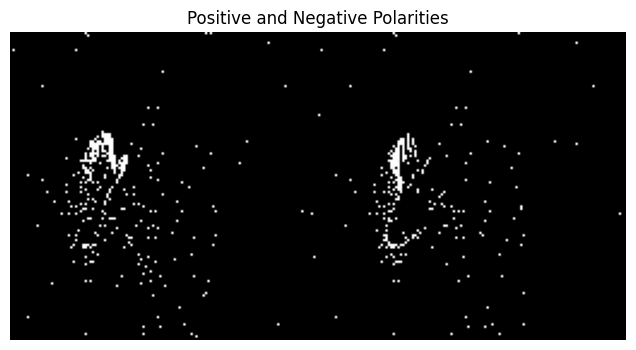

In [9]:
# Step 2: Visualize the Frames inline in the notebook
fig, ax = plt.subplots(figsize=(10, 4))

for i, frame in enumerate(frames):

    # Concatenate the two polarities into a single frame for visualization
    concatenated_frame = np.hstack((
        cv2.cvtColor(frame[0].astype(np.uint8) * 255, cv2.COLOR_GRAY2BGR),  # Positive events
        cv2.cvtColor(frame[1].astype(np.uint8) * 255, cv2.COLOR_GRAY2BGR)   # Negative events
    ))

    # Convert BGR to RGB for correct matplotlib colors
    rgb_frame = cv2.cvtColor(concatenated_frame, cv2.COLOR_BGR2RGB)

    ax.clear()
    ax.imshow(rgb_frame)
    ax.set_title('Positive and Negative Polarities')
    ax.axis('off')

    clear_output(wait=True)
    display(fig)
    time.sleep(0.03)

plt.close(fig)

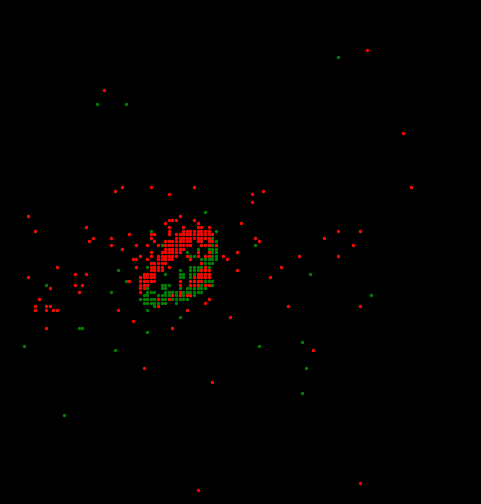

In [5]:
# Visualize both polarities in a separate cell using colored dots on a black background.
fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

for i, frame in enumerate(frames):

    ax.clear()
    ax.set_facecolor('black')

    # Positive events in green.
    pos_y, pos_x = np.where(frame[0] > 0)
    ax.scatter(pos_x, pos_y, c='green', s=2, label='Positive events')

    # Negative events in red.
    neg_y, neg_x = np.where(frame[1] > 0)
    ax.scatter(neg_x, neg_y, c='red', s=2, label='Negative events')

    ax.set_title('Positive and Negative Events')
    ax.set_xlim(0, frame.shape[2])
    ax.set_ylim(frame.shape[1], 0)
    ax.set_aspect('equal')
    ax.axis('off')

    clear_output(wait=True)
    display(fig)
    time.sleep(0.03)

plt.close(fig)

## 5. Quantitative experiment: user_trial and time_window

Try experimenting with different values for `user_trial` and `time_window`.
How do these changes affect the visualization and interpretation of the data?

The next cell provides numerical metrics to support your interpretation.

In [6]:
# Compare different (user_trial, time_window) configurations with numerical outputs
test_configs = [
    (1, 5000),
    (1, 10000),
    (1, 20000),
    (5, 10000),
    (10, 10000),
]

def compute_metrics(dataset, trial, tw):
    ev, _ = dataset[trial]
    tr = tonic.transforms.ToFrame(
        sensor_size=dataset.sensor_size,
        time_window=tw
    )
    fr = tr(ev)

    events_per_frame = fr.sum(axis=(1, 2, 3))
    num_frames = int(len(fr))
    total_events = int(len(ev))
    mean_events_per_frame = float(events_per_frame.mean()) if num_frames > 0 else 0.0
    std_events_per_frame = float(events_per_frame.std()) if num_frames > 0 else 0.0
    non_empty_ratio = float((events_per_frame > 0).mean()) if num_frames > 0 else 0.0

    return {
        "user_trial": trial,
        "time_window_us": tw,
        "num_frames": num_frames,
        "total_events": total_events,
        "mean_events_per_frame": mean_events_per_frame,
        "std_events_per_frame": std_events_per_frame,
        "non_empty_frame_ratio": non_empty_ratio,
    }

results = [compute_metrics(dvs_training, trial, tw) for trial, tw in test_configs]

print("Numerical comparison across configurations:\n")
for row in results:
    print(
        f"trial={row['user_trial']:>2}, tw={row['time_window_us']:>5} us | "
        f"frames={row['num_frames']:>4}, total_events={row['total_events']:>7}, "
        f"mean/frame={row['mean_events_per_frame']:.2f}, std/frame={row['std_events_per_frame']:.2f}, "
        f"non_empty_ratio={row['non_empty_frame_ratio']:.2f}"
    )

# Quick interpretation helpers
print("\nInterpretation hints:")
print("- Smaller time_window -> usually more frames, fewer events per frame.")
print("- Larger time_window  -> usually fewer frames, denser frames (more events/frame).")
print("- Changing user_trial may change total activity and temporal dynamics.")

Numerical comparison across configurations:

trial= 1, tw= 5000 us | frames=1064, total_events= 431830, mean/frame=405.76, std/frame=90.85, non_empty_ratio=1.00
trial= 1, tw=10000 us | frames= 532, total_events= 431830, mean/frame=811.51, std/frame=176.01, non_empty_ratio=1.00
trial= 1, tw=20000 us | frames= 266, total_events= 431830, mean/frame=1623.02, std/frame=344.98, non_empty_ratio=1.00
trial= 5, tw=10000 us | frames= 421, total_events= 161909, mean/frame=383.67, std/frame=121.03, non_empty_ratio=1.00
trial=10, tw=10000 us | frames= 905, total_events= 897504, mean/frame=991.39, std/frame=369.29, non_empty_ratio=1.00

Interpretation hints:
- Smaller time_window -> usually more frames, fewer events per frame.
- Larger time_window  -> usually fewer frames, denser frames (more events/frame).
- Changing user_trial may change total activity and temporal dynamics.


## Exercise

**GOAL:** Quantify the **total number of events** and the **sparsity** for `user_trial = 67`.

**Expected Output:** 
- `total events` (integer);
- `sparsity (%)` in [0, 100].

In [7]:
# TODO: compute the total number of events and the sparsity for the specific user_trial

user_trial = 67

total_events = None  
sparsity = None      

if total_events is None or sparsity is None:
    raise NotImplementedError("TODO: compute the total number of events and the sparsity")

print(f"Total number of events: {total_events}")
print(f"Sparsity: {sparsity:.2f}%")

NotImplementedError: TODO: compute the total number of events and the sparsity

## Questions:

1. Try experimenting with different values for **user_trial** and **time_window**. How do these changes affect the visualization and interpretation of the data?